In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../database/database.db")

query = """
SELECT 
    s.weekly_sales,
    s.store_id,
    s.holiday_flag,
    e.temperature,
    e.fuel_price,
    e.cpi,
    e.unemployment
FROM Sales s
JOIN External_Factors e
ON s.store_id = e.store_id AND s.date = e.date;
"""

df = pd.read_sql_query(query, conn)

df.head()

,weekly_sales,store_id,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1643690.90,1,0,42.31,2.572,211.096358,8.106
1,1641957.44,1,1,38.51,2.548,211.242170,8.106
2,1554806.68,1,0,46.50,2.625,211.350143,8.106
3,1439541.59,1,0,57.79,2.667,211.380643,8.106
4,1594968.28,1,0,62.27,2.719,210.820450,7.808


In [2]:
from sklearn.model_selection import train_test_split

# Features (X)
X = df.drop("weekly_sales", axis=1)

# Target (y)
y = df["weekly_sales"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [4]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"{model_name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("-" * 30)

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Linear Regression
MAE: 451261.3358329841
RMSE: 533931.0742674497
------------------------------
Random Forest
MAE: 60799.86409551655
RMSE: 100846.70224270165
------------------------------


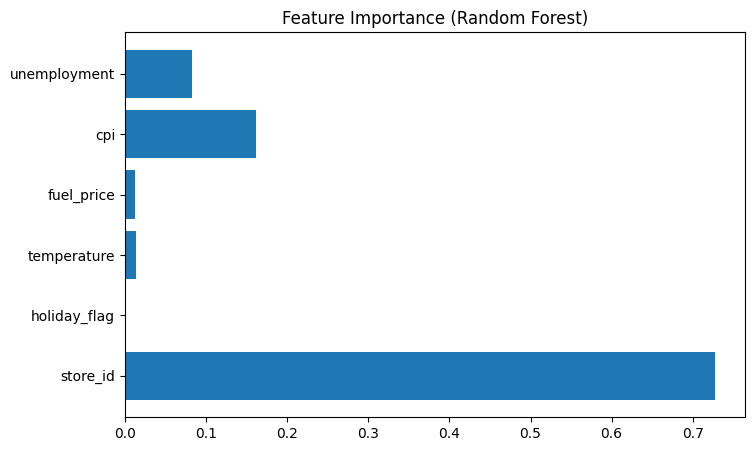

In [6]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()